<div dir="rtl" style="text-align: right;">

# Classwork — استفاده عملی از Multi-Head Attention

**مدت پیشنهادی:** حدود ۲ ساعت  
**ابزار اصلی:** <span dir="ltr">PyTorch `nn.MultiheadAttention`</span>

## هدف جلسه

در این تمرین قرار نیست دوباره فرمول Attention را از ابتدا پیاده‌سازی کنید.

هدف این است که ببینید چگونه می‌توان از <span dir="ltr">Multi-Head Attention</span> در یک pipeline ساده و واقعی استفاده کرد.

مدل ما پیام‌های کوتاه پشتیبانی را در سه گروه قرار می‌دهد:

- <span dir="ltr">`account`</span>
- <span dir="ltr">`billing`</span>
- <span dir="ltr">`technical`</span>

مسیر کلی مدل:

</div>

```text
Text
 ↓
Token IDs
 ↓
Embedding
 ↓
MultiheadAttention
 ↓
Masked Mean Pooling
 ↓
Linear Classifier
 ↓
account / billing / technical
```

<div dir="rtl" style="text-align: right;">

در پایان جلسه باید بتوانید:

- از <span dir="ltr">`nn.MultiheadAttention`</span> استفاده کنید.
- shapeهای اصلی را تشخیص دهید.
- <span dir="ltr">padding mask</span> را درست بسازید.
- خروجی tokenها را به یک representation برای کل جمله تبدیل کنید.
- اثر mask اشتباه را در یک مثال واقعی ببینید.

</div>

In [1]:
import re
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(10)
random.seed(10)

LABELS = ["account", "billing", "technical"]
label_to_id = {label: i for i, label in enumerate(LABELS)}
id_to_label = {i: label for label, i in label_to_id.items()}

print(f"label_to_id:\n{label_to_id}\n")
print(f"id_to_label:\n{id_to_label}\n")

train_examples = [
    ("I cannot log into my account", "account"),
    ("My password does not work", "account"),
    ("I forgot my password", "account"),
    ("My account is locked", "account"),
    ("The login code never arrives", "account"),
    ("Please reset my password", "account"),

    ("My invoice has the wrong amount", "billing"),
    ("I was charged twice", "billing"),
    ("The payment failed", "billing"),
    ("I need my receipt", "billing"),
    ("My bill is too high", "billing"),
    ("The refund has not arrived", "billing"),

    ("The app crashes when I open it", "technical"),
    ("The website is very slow", "technical"),
    ("The page does not load", "technical"),
    ("The app freezes after startup", "technical"),
    ("I see an error message", "technical"),
    ("The screen stays blank", "technical"),
]

test_examples = [
    ("My account login is locked", "account"),
    ("I need to reset my password", "account"),
    ("My invoice has an extra charge", "billing"),
    ("My payment was charged twice", "billing"),
    ("The app shows an error", "technical"),
    ("The website page does not load", "technical"),
]

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

all_examples = train_examples + test_examples
print(f"all_examples:\n{all_examples}\n")

all_words = sorted({
    token
    for text, _ in all_examples
    for token in tokenize(text)
})

print(f"All words:\n{all_words}\n")

vocab = ["<PAD>", "<UNK>"] + all_words
print(f"Vocab:\n{(vocab)}\n")

stoi = {token: i for i, token in enumerate(vocab)}
print(f"Stoi:\n{stoi}\n")

itos = {i: token for token, i in stoi.items()}
print(f"Itos:\n{itos}\n")

PAD_ID = stoi["<PAD>"]
UNK_ID = stoi["<UNK>"]
MAX_LEN = 10

def encode_text(text, max_len=MAX_LEN):
    ids = [stoi.get(token, UNK_ID) for token in tokenize(text)]
    ids = ids[:max_len]
    # print(ids)
    ids += [PAD_ID] * (max_len - len(ids))
    return ids

encode_text("I need to reset my password", 8)

label_to_id:
{'account': 0, 'billing': 1, 'technical': 2}

id_to_label:
{0: 'account', 1: 'billing', 2: 'technical'}

all_examples:
[('I cannot log into my account', 'account'), ('My password does not work', 'account'), ('I forgot my password', 'account'), ('My account is locked', 'account'), ('The login code never arrives', 'account'), ('Please reset my password', 'account'), ('My invoice has the wrong amount', 'billing'), ('I was charged twice', 'billing'), ('The payment failed', 'billing'), ('I need my receipt', 'billing'), ('My bill is too high', 'billing'), ('The refund has not arrived', 'billing'), ('The app crashes when I open it', 'technical'), ('The website is very slow', 'technical'), ('The page does not load', 'technical'), ('The app freezes after startup', 'technical'), ('I see an error message', 'technical'), ('The screen stays blank', 'technical'), ('My account login is locked', 'account'), ('I need to reset my password', 'account'), ('My invoice has an extra charge', 'bi

[24, 35, 53, 45, 34, 40, 0, 0]

<div dir="rtl" style="text-align: right;">

# بخش 1 — Batch و Padding Mask

جمله‌ها طول یکسان ندارند، بنابراین برای ساختن یک batch باید جمله‌های کوتاه‌تر را با <span dir="ltr">`<PAD>`</span> پر کنیم.

مثال:

</div>

```text
I forgot my password <PAD> <PAD>
The page does not load <PAD>
```

<div dir="rtl" style="text-align: right;">

اما نمی‌خواهیم Attention از موقعیت‌های <span dir="ltr">`<PAD>`</span> به‌عنوان اطلاعات واقعی استفاده کند.

برای همین از <span dir="ltr">`key_padding_mask`</span> استفاده می‌کنیم.

در <span dir="ltr">PyTorch</span>:

<div dir="ltr" style="text-align: left;">

`True = ignore this position`

</div>

### سؤال 1

تابع زیر را کامل کنید تا:

- <span dir="ltr">`input_ids`</span> ساخته شود.
- <span dir="ltr">`padding_mask`</span> برای موقعیت‌های <span dir="ltr">`<PAD>`</span> مقدار <span dir="ltr">`True`</span> داشته باشد.

سپس shape هر دو tensor را چاپ کنید.

</div>

In [2]:
def make_batch(items):
    input_ids = torch.tensor(
        [encode_text(text) for text, _ in items],
        dtype=torch.long,
    )

    labels = torch.tensor(
        [label_to_id[label] for _, label in items],
        dtype=torch.long,
    )

    # TODO:
    # True must correspond to PAD positions.
    padding_mask = input_ids == 0

    return input_ids, padding_mask, labels


input_ids, padding_mask, labels = make_batch(train_examples[:4])

print("input_ids shape   :", input_ids.shape)
print("padding_mask shape:", padding_mask.shape)

print("\ninput_ids:\n", input_ids)
print("\npadding_mask:\n", padding_mask)
print("\nlabels:\n", labels)

input_ids shape   : torch.Size([4, 10])
padding_mask shape: torch.Size([4, 10])

input_ids:
 tensor([[24, 11, 31, 25, 34,  2,  0,  0,  0,  0],
        [34, 40, 16, 37, 60,  0,  0,  0,  0,  0],
        [24, 20, 34, 40,  0,  0,  0,  0,  0,  0],
        [34,  2, 27, 30,  0,  0,  0,  0,  0,  0]])

padding_mask:
 tensor([[False, False, False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True,  True,  True]])

labels:
 tensor([0, 0, 0, 0])


<div dir="rtl" style="text-align: right;">

### بررسی سریع

کدی بنویسید که بررسی کند تعداد مقدارهای <span dir="ltr">`True`</span> در mask با تعداد <span dir="ltr">`PAD_ID`</span>ها برابر است.

</div>

In [3]:
# TODO:
# assert ...
assert padding_mask.sum().item() == (input_ids == PAD_ID).sum().item(), "Mismatch Error!"

<div dir="rtl" style="text-align: right;">

# بخش 2 — استفاده از MultiheadAttention

اکنون هر token را به یک embedding تبدیل می‌کنیم و سپس sequence را وارد <span dir="ltr">`MultiheadAttention`</span> می‌کنیم.

در اینجا:

<div dir="ltr" style="text-align: left;">

`Q = K = V = X`

</div>

بنابراین Attention از نوع <span dir="ltr">Self-Attention</span> است.

از تنظیمات زیر استفاده کنید:

- <span dir="ltr">`d_model = 32`</span>
- <span dir="ltr">`num_heads = 4`</span>
- <span dir="ltr">`batch_first = True`</span>

### سؤال 2

کد مدل را کامل کنید.

سپس برای یک batch با shape برابر <span dir="ltr">`[4, 10]`</span>، shapeهای زیر را گزارش کنید:

- خروجی Embedding
- خروجی Attention
- وزن‌های Attention

</div>

In [4]:
class SimpleAttentionClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_classes,
        pad_id,
        d_model=32,
        num_heads=4,
    ):
        super().__init__()

        self.pad_id = pad_id

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_id,
        )

        # TODO:
        self.attention = nn.MultiheadAttention(d_model, num_heads,batch_first=True)

        self.classifier = nn.Linear(
            d_model,
            num_classes,
        )

    def forward(
        self,
        input_ids,
        use_padding_mask=True,
        return_weights=False,
    ):

        x = self.embedding(input_ids)

        if use_padding_mask:
            key_padding_mask = input_ids.eq(self.pad_id)
        else:
            key_padding_mask = None

        attn_out, attn_weights = self.attention(
            x,
            x,
            x,
            key_padding_mask=key_padding_mask,
            need_weights=return_weights,
            average_attn_weights=False,
        )

        # We want one vector for each sentence.
        # Ignore PAD positions when taking the mean.
        valid = input_ids.ne(self.pad_id).unsqueeze(-1)

        masked_out = attn_out * valid

        sentence_vector = (
            masked_out.sum(dim=1)
            / valid.sum(dim=1).clamp_min(1)
        )

        logits = self.classifier(sentence_vector)

        return logits, attn_weights, x, attn_out


model = SimpleAttentionClassifier(
    vocab_size=len(vocab),
    num_classes=len(LABELS),
    pad_id=PAD_ID,
)

demo_ids, demo_mask, demo_y = make_batch(train_examples[:4])

logits, weights, emb, attn_out = model(
    demo_ids,
    return_weights=True,
)

print("embedding:", emb.shape)
print("attention output:", attn_out.shape)
print("attention weights:", weights.shape)
print("logits:", logits.shape)

embedding: torch.Size([4, 10, 32])
attention output: torch.Size([4, 10, 32])
attention weights: torch.Size([4, 4, 10, 10])
logits: torch.Size([4, 3])


<div dir="rtl" style="text-align: right;">

### سؤال 2B

در دو یا سه جمله توضیح دهید:

1. چرا خروجی Attention هنوز برای هر token یک vector جدا دارد؟

چون خروجی اتنشن یک بردار context هست
برای هر توکن که طولش روبرابر با خروجی embedding قرار دادیم

2. چرا قبل از Linear classifier از <span dir="ltr">Masked Mean Pooling</span> استفاده کردیم؟

برای هر جمله یک رپرزنتیشن واحد از امبدینگ درست میکنیم
adaptiveAverage poolروی فیچر مپ های کانولوشنی عملی مشابه این عمل در پردازش تصویر بود
</div>

<div dir="rtl" style="text-align: right;">

# بخش 3 — Training ساده

اکنون مدل را روی داده‌های کوچک بالا train می‌کنیم.

در زمان training این بخش‌ها همگی قابل یادگیری هستند:

- <span dir="ltr">Embedding</span>
- پارامترهای داخلی <span dir="ltr">MultiheadAttention</span>
- <span dir="ltr">Linear classifier</span>

### کار شما

cell زیر را اجرا کنید و:

1. نمودار loss را ببینید.
2. <span dir="ltr">train accuracy</span> و <span dir="ltr">test accuracy</span> را گزارش کنید.
3. اگر test accuracy از train accuracy کمتر بود، در یک جمله توضیح دهید چرا این موضوع عجیب نیست.

</div>

E:\Maktab-145\maktab_kernel\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: The detected GPU (Intel(R) UHD Graphics) is not officially supported by PyTorch XPU. Running workloads on this device may result in unexpected behavior.
For stable and fully supported execution, please use GPUs based on Intel Arc (Alchemist) series or newer.
Refer to the hardware prerequisites for more information: https://docs.pytorch.org/docs/main/notes/get_start_xpu.html#hardware-prerequisite (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\xpu\XPUFunctions.cpp:134.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
C:\Users\S.Amir Mahdi\AppData\Local\Temp\ipykernel_10604\675208191.py:37: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\pyt

train accuracy: 1.0
test accuracy: 0.8333333134651184


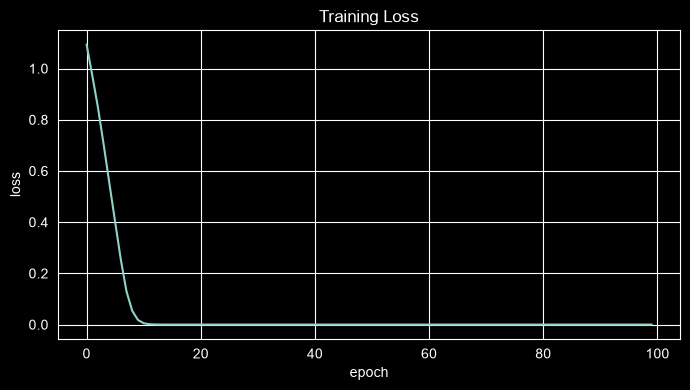

In [5]:
train_ids, train_mask, train_y = make_batch(train_examples)
test_ids, test_mask, test_y = make_batch(test_examples)

torch.manual_seed(10)

model = SimpleAttentionClassifier(
    vocab_size=len(vocab),
    num_classes=len(LABELS),
    pad_id=PAD_ID,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
)

loss_history = []

for epoch in range(100):
    model.train()

    optimizer.zero_grad()

    logits, _, _, _ = model(
        train_ids,
        use_padding_mask=True,
    )

    loss = F.cross_entropy(
        logits,
        train_y,
    )

    loss.backward()
    optimizer.step()

    loss_history.append(float(loss))


def get_accuracy(model, ids, y):
    model.eval()

    with torch.no_grad():
        logits, _, _, _ = model(
            ids,
            use_padding_mask=True,
        )

    pred = logits.argmax(dim=-1)

    return (
        (pred == y)
        .float()
        .mean()
        .item()
    )


print(
    "train accuracy:",
    get_accuracy(
        model,
        train_ids,
        train_y,
    ),
)

print(
    "test accuracy:",
    get_accuracy(
        model,
        test_ids,
        test_y,
    ),
)

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training Loss")
plt.tight_layout()
plt.show()

```report
train accuracy: 1.0
test accuracy: 0.8333333134651184
```
تعداد جمله ها بسیار کم است
ظرفیت مدل برای این حجم از داده زیاد است و این مسئله باعث memorize کردن داده های آموزش شده 

<div dir="rtl" style="text-align: right;">

# بخش 4 — چرا Padding Mask مهم است؟

در این آزمایش، یک جمله را دو بار وارد مدل می‌کنیم.

محتوای واقعی جمله یکسان است، اما در نسخه دوم تعداد بیشتری <span dir="ltr">`<PAD>`</span> وجود دارد.

اگر mask درست باشد، اضافه شدن padding نباید اثر زیادی روی prediction داشته باشد.

### کار شما

کد زیر را اجرا کنید و نتیجه دو حالت را مقایسه کنید:

- با <span dir="ltr">padding mask</span>
- بدون <span dir="ltr">padding mask</span>

</div>

In [6]:
def encode_with_length(text, total_length):
    ids = [
        stoi.get(token, UNK_ID)
        for token in tokenize(text)
    ]

    ids = ids[:total_length]
    ids += [PAD_ID] * (
        total_length - len(ids)
    )

    return torch.tensor(
        ids,
        dtype=torch.long,
    ).unsqueeze(0)


text = "The app crashes when I open it"

short_version = encode_with_length(
    text,
    8,
)

long_version = encode_with_length(
    text,
    30,
)


def get_probs(model, ids, use_padding_mask):
    model.eval()

    with torch.no_grad():
        logits, _, _, _ = model(
            ids,
            use_padding_mask=use_padding_mask,
        )

        return torch.softmax(
            logits,
            dim=-1,
        ).squeeze(0)


print("WITH MASK")

print(
    "length 8 :",
    get_probs(
        model,
        short_version,
        True,
    ),
)

print(
    "length 30:",
    get_probs(
        model,
        long_version,
        True,
    ),
)


print("\nWITHOUT MASK")

print(
    "length 8 :",
    get_probs(
        model,
        short_version,
        False,
    ),
)

print(
    "length 30:",
    get_probs(
        model,
        long_version,
        False,
    ),
)

WITH MASK
length 8 : tensor([9.4144e-19, 7.0650e-14, 1.0000e+00])
length 30: tensor([9.4144e-19, 7.0650e-14, 1.0000e+00])

WITHOUT MASK
length 8 : tensor([1.5112e-17, 5.9287e-13, 1.0000e+00])
length 30: tensor([2.7743e-09, 1.4961e-06, 1.0000e+00])


<div dir="rtl" style="text-align: right;">

### سؤال 4

به خروجی‌ها نگاه کنید و پاسخ دهید:

1. در کدام حالت، تغییر تعداد <span dir="ltr">`<PAD>`</span> اثر بیشتری روی خروجی مدل دارد؟
حالت False
2. این آزمایش چه چیزی درباره اهمیت <span dir="ltr">padding mask</span> نشان می‌دهد؟
اگر از مسک استفاده نشود پدینگ ها به عنوان ویژگی های مدل آموزش میبینند و خروجی ها متفاوت میشود !

</div>

<div dir="rtl" style="text-align: right;">

# تمرین کوتاه پایانی — Debugging

کد زیر اشتباه است:

<div dir="ltr" style="text-align: left;">

```python
key_padding_mask = input_ids != PAD_ID
```

</div>

### سؤال

اشتباه چیست؟
مشکل این کد این است که مواردی که برابر نیست رو دارد به عنوان پدینگ نشان میدهد یعنی کاملا برعکس است

نسخه صحیح را بنویسید و توضیح دهید در <span dir="ltr">PyTorch MultiheadAttention</span> مقدار <span dir="ltr">`True`</span> در این mask چه معنی دارد.

```python
key_padding_mask = input_ids == PAD_ID
```
در پایتورچ موارد True مساوی است با مواردی که نباید گرادیان روی آنها اثر بگذارد و اپتیمایزر نباید آنها را آپدیت کند چرا که پدینگ یا فیچر های 0 مصنوعی هستند که توسط ما تولید شده اند و ارزش یادگیری ندارد
</div>

<div dir="rtl" style="text-align: right;">

# جمع‌بندی

تا اینجا یک pipeline کامل ساخته‌اید:

</div>

```text
Text
 ↓
Tokenization
 ↓
Padding
 ↓
Embedding
 ↓
Multi-Head Self-Attention
 ↓
Masked Mean Pooling
 ↓
Linear Classifier
 ↓
Prediction
```

<div dir="rtl" style="text-align: right;">

مهم‌ترین نکات این جلسه:

- <span dir="ltr">MultiheadAttention</span> برای هر token یک representation جدید تولید می‌کند.
- برای classification به یک representation برای کل جمله نیاز داریم.
- در این تمرین این representation را با <span dir="ltr">Masked Mean Pooling</span> ساختیم.
- موقعیت‌های <span dir="ltr">`<PAD>`</span> نباید در Attention یا pooling وارد شوند.
- <span dir="ltr">Embedding</span>، <span dir="ltr">Attention</span> و classifier می‌توانند با هم train شوند.

</div>

<div dir="rtl" style="text-align: right;">

# Reference

<div dir="ltr" style="text-align: left;">

PyTorch — `nn.MultiheadAttention`  
https://docs.pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html

Vaswani et al. (2017) — *Attention Is All You Need*  
Section 3.2.2: Multi-Head Attention  
https://arxiv.org/abs/1706.03762

</div>

</div>